> ISA 444 Final Project \(ML Models\)

### Install Libraries

In [80]:
!pip install mlforecast utilsforecast scikit-learn lightgbm pandas
import pandas as pd
import holidays
from sklearn.linear_model import Lasso 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean

from utilsforecast.evaluation import evaluate
from utilsforecast.plotting import plot_series
from utilsforecast.losses import bias, mae, rmse, mape
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### Load Dataset and Transform

In [82]:
us_holidays = holidays.US(years=range(2020, 2024))

df = (
    pd.read_parquet("/work/sample_hotels.parquet")
    .query("unique_id not in ['hotel_77', 'hotel_28']")
    .drop(columns=['target_month', 'target_year', 'location_type'])
    .assign(
        ds = lambda x: pd.to_datetime(x["ds"]),
        unique_id = lambda x: x["unique_id"].astype(str),
        y = lambda x: x["y"].astype(float),

        hotel_type = lambda x: x['hotel_type'].astype('category'),
        # create holiday_name from holiday_flag
        holiday_name = lambda x: (
            x['ds'].dt.date.apply(lambda y: us_holidays.get(y))
            .astype('category')
            .cat.add_categories('None')
            .fillna('None')
        ),
        # create day_of_week from the actual timestamp
        day_of_week = lambda x: x.ds.dt.day_name().astype('category')
    )
    # drop holiday_flag and target_day now that we have holiday_name and day_of_week
    .drop(columns=['holiday_flag', 'target_day']) 
)

# transform categories into binary variables
df = pd.get_dummies(df, columns=['day_of_week', 'holiday_name', 'hotel_type'], drop_first=True)

cols_to_keep = [
    col for col in df.columns 
    if not col.startswith('otb_') or col in ['otb_28', 'otb_30', 'otb_46']
]

df = df[cols_to_keep]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9282 entries, 1430 to 298041
Data columns (total 29 columns):
 #   Column                                                        Non-Null Count  Dtype         
---  ------                                                        --------------  -----         
 0   unique_id                                                     9282 non-null   object        
 1   ds                                                            9282 non-null   datetime64[us]
 2   y                                                             9282 non-null   float64       
 3   otb_28                                                        9282 non-null   float64       
 4   otb_30                                                        9282 non-null   float64       
 5   otb_46                                                        9282 non-null   float64       
 6   day_of_week_Monday                                            9282 non-null   bool          
 7   day_of

In [112]:
# Split data and declare panel dataset
train = df.query("ds <= '2023-06-03'")
test = df.query("ds > '2023-06-03'")

ml_models = {
    'Lasso': Lasso(),
    'KNN': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(),
    'LightGBM': LGBMRegressor(),
}

ml = MLForecast(
    models=ml_models,
    freq='D',
    lags=list(range(28, 57)) + [60, 90], 
    lag_transforms={
        # Trends from 4 weeks ago:
        28: [
            RollingMean(window_size=7), 
            RollingMean(window_size=14)
        ]
    },
    date_features=['year', 'month']
)

cross_ml = ml.cross_validation(
    df=train,                   
    n_windows=6,            
    h=28,                   
    step_size=28,           
    static_features=[]       

)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9210
[LightGBM] [Info] Number of data points in the train set: 4437, number of used features: 47
[LightGBM] [Info] Start training from score 0.729883
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000936 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9214
[LightGBM] [Info] Number of data points in the train set: 4913, number of used features: 48
[LightGBM] [Info] Start training from score 0.719894
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of test

In [128]:
ml.fit(train, static_features=[])

dynamic_cols = [col for col in train.columns if col not in ['unique_id', 'ds', 'y']]
forecasts_df = ml.predict(h=test['ds'].nunique(), X_df=test[['unique_id', 'ds'] + dynamic_cols])

eval_test_df = forecasts_df.merge(test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

# Evaluate the predictions
eval_ml = evaluate(
    df = eval_test_df, 
    metrics = [bias, mae, rmse, mape],
    models=['Lasso', 'KNN', 'Random Forest', 'LightGBM'],
    target_col='y' 
)

eval_summary = eval_ml.groupby(['unique_id','metric']).mean().reset_index(inplace=False)
print(eval_summary)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9218
[LightGBM] [Info] Number of data points in the train set: 7293, number of used features: 49
[LightGBM] [Info] Start training from score 0.719917
    unique_id metric     Lasso       KNN  Random Forest  LightGBM
0     hotel_0   bias -0.008478 -0.026778       0.008943  0.031714
1     hotel_0    mae  0.100335  0.074270       0.059539  0.067779
2     hotel_0   mape  0.146539  0.104930       0.089345  0.101811
3     hotel_0   rmse  0.127167  0.095360       0.078201  0.083480
4   hotel_105   bias -0.276822 -0.094102      -0.083803 -0.056917
..        ...    ...       ...       ...            ...       ...
63   hotel_91   rmse  0.205627  0.159861       0.081367  0.070953
64   hotel_98   bias  0.539212 -0.008005       0.04

In [130]:
import pandas as pd

# 1. Melt the data so models are in a single column for easier comparison
id_vars = ['unique_id', 'metric']
model_cols = ['Lasso', 'KNN', 'Random Forest', 'LightGBM']
melted_eval = eval_summary.melt(id_vars=id_vars, value_vars=model_cols, var_name='model', value_name='score')

# 2. Define which metrics we want to MINIMIZE (MAE, RMSE, MAPE) vs those where 0 is best (Bias)
# For simplicity, we'll treat the absolute value of bias as the "score" to minimize
melted_eval['abs_score'] = melted_eval.apply(
    lambda x: abs(x['score']) if x['metric'] == 'bias' else x['score'], axis=1
)

# 3. Determine the "Winner" for each hotel/metric pair
wins = (
    melted_eval.sort_values('abs_score')
    .groupby(['unique_id', 'metric'])
    .head(1) # Pick the model with the lowest error
)

# 4. Aggregate the Win Counts
model_wins = wins['model'].value_counts().reset_index()
model_wins.columns = ['Model', 'Total Wins (Across all Metrics/Hotels)']

print("--- Model Win Counts ---")
print(model_wins)

# 5. Final Summary: Mean Metric per Model
final_summary = eval_summary.groupby('metric')[model_cols].mean()
print("\n--- Average Performance per Model ---")
print(final_summary)

--- Model Win Counts ---
           Model  Total Wins (Across all Metrics/Hotels)
0       LightGBM                                      43
1          Lasso                                       9
2  Random Forest                                       9
3            KNN                                       7

--- Average Performance per Model ---
           Lasso       KNN  Random Forest  LightGBM
metric                                             
bias   -0.049666 -0.034459       0.002452  0.011543
mae     0.195466  0.100707       0.088507  0.081811
mape    0.558113  0.179497       0.156451  0.143835
rmse    0.213414  0.123509       0.106010  0.098852


### Generate final test forecasts and export results to CSV

In [132]:
df.to_csv('ML_Output.csv', index=False)

### Create forecast\-vs\-actual plots for every series

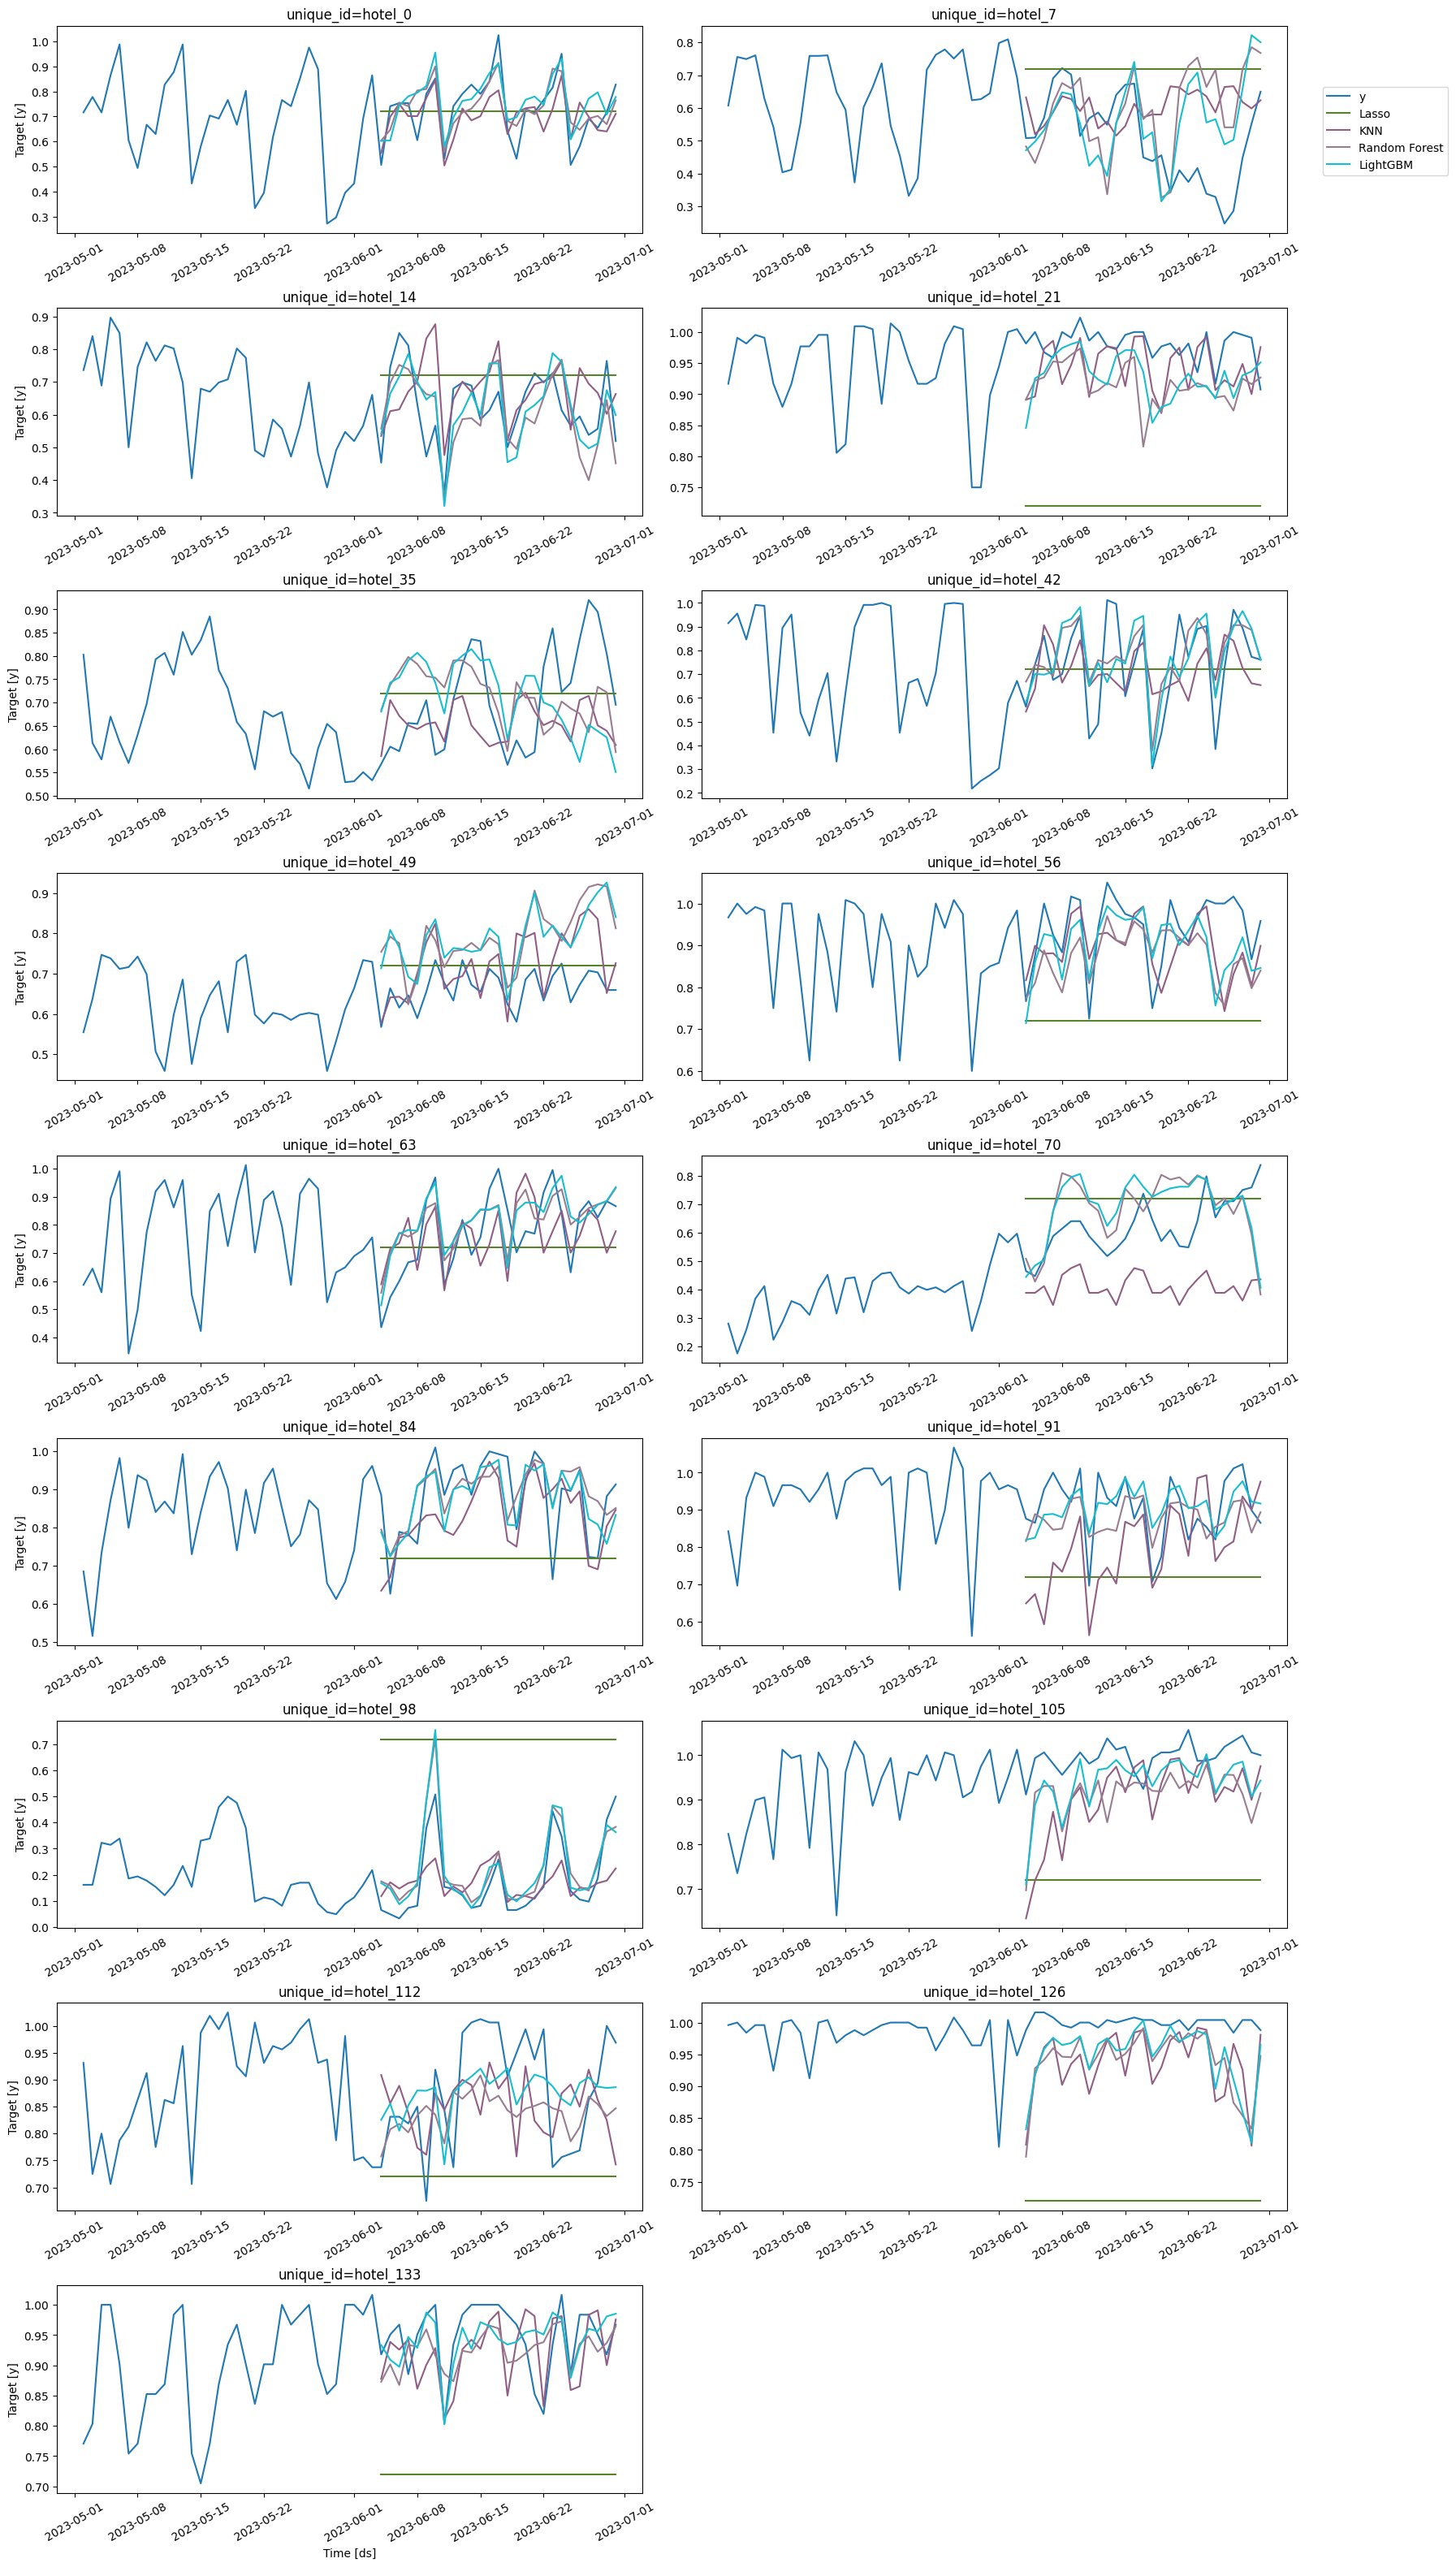

In [148]:
# 1. Get the list of all unique hotel IDs to plot
all_hotels = df['unique_id'].unique().tolist()

# 2. Generate the grid of plots
# We pass 'df' for the actual history and 'forecasts_df' for the predictions
plot_series(
    df, 
    forecasts_df, 
    ids=all_hotels,           # Plot every hotel ID
    max_ids=17,               # Display all 17 hotels in the grid
    max_insample_length=60,   # Show the last 60 days of history for context
    models=['Lasso', 'KNN', 'Random Forest', 'LightGBM'],
    target_col='y'
)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f83e4db7-0c23-436a-9211-ebdab13126d5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>